In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/insurance.csv")
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.region.unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [8]:
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy

,age,bmi,children,charges,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [12]:
target = "charges"
y = df_dummy[target] # label, target, outcome
X = df_dummy.drop(columns=target)
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [13]:
X

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [9]:
from sklearn import model_selection

In [14]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3) # random split

In [15]:
len(X_train)/ len(X)

0.6995515695067265

In [16]:
len(X_test)/ len(X)

0.3004484304932735

In [17]:
import numpy as np

In [33]:
np.random.randint(0, 10, 3)

array([0, 6, 9])

In [44]:
np.random.seed(42342342) # seed any arbitrary int value
np.random.randint(0, 10, 3)

array([0, 8, 5])

In [62]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
                                    , test_size=0.3, random_state=44234234) # random split
print(X_train)

      age     bmi  children  gender_male  smoker_yes  region_northwest  \
874    44  21.850         3         True       False             False   
179    41  33.155         3        False       False             False   
803    18  42.240         0        False        True             False   
806    40  41.420         1        False       False              True   
1207   36  33.400         2         True        True             False   
...   ...     ...       ...          ...         ...               ...   
1129   19  18.600         0        False       False             False   
697    41  35.750         1         True        True             False   
139    22  36.000         0        False       False             False   
1040   35  28.025         0        False        True              True   
1097   22  33.770         0         True       False             False   

      region_southeast  region_southwest  
874              False             False  
179              False   

In [63]:
from sklearn.linear_model import LinearRegression

In [65]:
est = LinearRegression()
est.fit(X_train, y_train) # learning process

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 253.01, 326.68, 562.96,..., -110.68, -676.96,-1336.46]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.143e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [66]:
y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

In [68]:
a = pd.DataFrame({"y": y_train, "y_pred": y_train_pred})
a["error"] = y_train-y_train_pred
a

,y,y_pred,error
874,8891.13950,8126.073280,765.066220
179,8538.28845,11460.934695,-2922.646245
803,38792.68560,30219.507359,8573.178241
806,28476.73499,12671.338036,15805.396954
1207,38415.47400,31951.544763,6463.929237
...,...,...,...
1129,1728.89700,-1885.539941,3614.436941
697,40273.64550,34080.844992,6192.800508
139,2166.73200,4557.749587,-2391.017587
1040,20234.85475,30443.249992,-10208.395242


<Axes: xlabel='y', ylabel='error'>

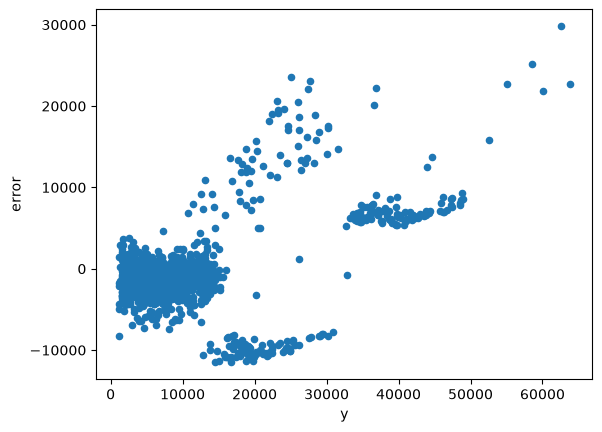

In [69]:
a.plot.scatter("y", "error")

<Axes: ylabel='Frequency'>

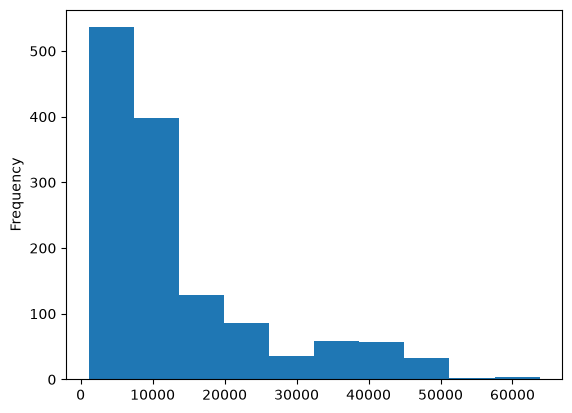

In [70]:
y.plot.hist()

In [74]:
est.intercept_ # intercepts 

np.float64(-11432.606373731733)

In [73]:
est.coef_ # coefficients

array([  253.01353098,   326.68097331,   562.95954273,  -400.77360467,
       23975.83079198,  -110.6822871 ,  -676.96492986, -1336.45675993])

In [75]:
X.columns

Index(['age', 'bmi', 'children', 'gender_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')

In [82]:
str(est.intercept_) + " + "+  str([f"{r[0]} x {r[1]}" for r in zip(X.columns, est.coef_)])

"-11432.606373731733 + ['age x 253.01353098225488', 'bmi x 326.680973307241', 'children x 562.959542733436', 'gender_male x -400.7736046675539', 'smoker_yes x 23975.83079198142', 'region_northwest x -110.6822871005152', 'region_southeast x -676.9649298633199', 'region_southwest x -1336.4567599326688']"

In [84]:
pd.DataFrame({"feature": X.columns, "cofficient": est.coef_})

,feature,cofficient
0,age,253.013531
1,bmi,326.680973
2,children,562.959543
3,gender_male,-400.773605
4,smoker_yes,23975.830792
5,region_northwest,-110.682287
6,region_southeast,-676.964930
7,region_southwest,-1336.456760


```
y_hat = -11432.606373731733 + 253.013531 age + 326.680973 * bmi + ...
```